# Fáza 3 - Strojové učenie

Kosharova, Oliinyk 50-50

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler, MinMaxScaler
import joblib
from sklearn.model_selection import learning_curve
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
metadata = joblib.load('../data/phase2_metadata.pkl')

In [3]:
y_train = pd.read_csv("data/splits/y_train.csv").squeeze()
y_test = pd.read_csv("data/splits/y_test.csv").squeeze()
X_train = pd.read_csv("data/splits/X_train.csv")
X_test = X_test = pd.read_csv("data/splits/X_test.csv")

In [4]:
pipeline = metadata['pipeline']

train_index = X_train.index
test_index = X_test.index

X_train = pipeline.transform(X_train)
X_test = pipeline.transform(X_test)

X_train= pd.DataFrame(
    X_train,
    columns=metadata['selected_features'],
    index=train_index
)

X_test = pd.DataFrame(
    X_test,
    columns=metadata['selected_features'],
    index=test_index
)

print(f"\nData shape:")
print(f"  Train: {X_train.shape}")
print(f"  Test:  {X_test.shape}")
print(f"Selected features: {list(X_train.columns)}")
print(f"\nTarget distribution:")
print(f"  Train:\n{y_train.value_counts()}")
print(f"  Test:\n{y_test.value_counts()}")


Data shape:
  Train: (17260, 7)
  Test:  (4315, 7)
Selected features: ['normal__HR', 'skewed__PRV', 'skewed__PVI', 'skewed__EtCO₂', 'skewed__Motion/Activity index', 'outliers__CO', 'bounded__SpO₂']

Target distribution:
  Train:
oximetry
1.0    10308
0.0     6952
Name: count, dtype: int64
  Test:
oximetry
1.0    2600
0.0    1715
Name: count, dtype: int64


## 3.1 Jednoduchý klasifikátor na základe závislosti v dátach

### 3.1a Jednoduchý ID3 klasifikátor

In [5]:
class Node:
    def __init__(self,
                 feature = None,
                 threshold = None,
                 value = None,
                 depth = 0,
                 left = None,
                 right = None ):
        self.feature = feature
        self.threshold = threshold
        self.depth = depth
        self.left = left
        self.right = right
        self.value = value

class ID3:
    def __init__(self, max_depth=2):
        self.max_depth = max_depth
        self.root = None
        self.features_names = None

    def entropy(self, y):
        n = np.bincount(y)
        p = n / len(y)
        return -np.sum([(p* np.log2(p)) for p in p if p > 0])

    def inf_gain(self, X, y, feature, threshold):
        full_entropy = self.entropy(y)

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        p_left = np.sum(left_mask) / len(y)
        p_right = np.sum(right_mask) / len(y)

        left_entropy = self.entropy(y[left_mask])
        right_entropy = self.entropy(y[right_mask])

        divided_entropy = p_left * left_entropy + p_right * right_entropy

        return full_entropy - divided_entropy

    def split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None

        for f in range(len(self.features_names)):
            thresholds = np.unique(X[:, f])
            for t in thresholds:
                gain = self.inf_gain(X, y, f, t)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = f
                    best_threshold = t

        return best_feature, best_threshold

    def build_tree(self, X, y, depth=0):
        n_features = X.shape[1]
        n_classes = len(np.unique(y))

        if depth >= self.max_depth or n_features == 1 or n_classes == 1:
            value = np.bincount(y).argmax()
            return Node(value=value, depth=depth)

        feature, threshold = self.split(X, y)

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        left_branch = self.build_tree(X[left_mask], y[left_mask], depth=depth+1)
        right_branch = self.build_tree(X[right_mask], y[right_mask], depth=depth+1)

        return Node(feature=feature,
                    threshold=threshold,
                    left=left_branch,
                    right=right_branch,
                    depth=depth)

    def fit(self, X, y):
        self.features_names = X.columns.tolist()
        X = X.values
        y = y.values
        y = y.astype(int)

        self.root = self.build_tree(X, y)

        return self

    def predict_value(self, x, node):
        if node.value is not None:
            return node.value

        if x[node.feature] <= node.threshold:
            return self.predict_value(x, node.left)
        else:
            return self.predict_value(x, node.right)

    def predict(self, X):
        X = X.values
        predictions = []
        for x in X:
            predictions.append(self.predict_value(x, self.root))
        return predictions

In [6]:
id3 = ID3(max_depth=3)
id3.fit(X_train, y_train)
id3_train = id3.predict(X_train)
id3_test = id3.predict(X_test)

### ID3 klasifikátor metríky accuracy, precision a recall

In [7]:
def get_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred)),
        "recall": float(recall_score(y_true, y_pred))
    }

In [8]:
id3_train_metrics = get_metrics(y_train, id3_train)
id3_test_metrics = get_metrics(y_test, id3_test)

print("ID3 classifier metrics")
print("\t\t\tTraining\tTesting")
print(f"Accuracy:\t{id3_train_metrics["accuracy"]:.2f}\t\t{id3_train_metrics["accuracy"]:.2f}")
print(f"Precision:\t{id3_train_metrics["precision"]:.2f}\t\t{id3_train_metrics["precision"]:.2f}")
print(f"Recall:\t\t{id3_train_metrics["recall"]:.2f}\t\t{id3_test_metrics["recall"]:.2f}")

ID3 classifier metrics
			Training	Testing
Accuracy:	0.83		0.83
Precision:	0.85		0.85
Recall:		0.87		0.86


### ID3 overfitting

In [9]:
gap = id3_train_metrics["accuracy"] - id3_test_metrics["accuracy"]

print(f"Training accuracy:  {id3_train_metrics["accuracy"]:.2f}")
print(f"Test accuracy:      {id3_test_metrics["accuracy"]:.2f}")
print(f"Train-tets gap:     {gap:.2f}")

if gap > 0.2:
    print("ID3 has overfitting (gap > 20%)")
else:
    print("There is not overfitting")

Training accuracy:  0.83
Test accuracy:      0.82
Train-tets gap:     0.01
There is not overfitting


## 3.2 Trénovanie a vyhodnotenie klasifikátorov strojového učenia

### 3.2a Stromový algoritmus v scikit-learn.

In [10]:
sklearn_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

sklearn_tree.fit(X_train, y_train)

tree_train = sklearn_tree.predict(X_train)
tree_test = sklearn_tree.predict(X_test)

tree_train_metrics = get_metrics(y_train, tree_train)
tree_test_metrics = get_metrics(y_test, tree_test)

print("Decision tree classifier metrics")
print("\t\t\tTraining\tTesting")
print(f"Accuracy:\t{tree_train_metrics["accuracy"]:.2f}\t\t{tree_test_metrics["accuracy"]:.2f}")
print(f"Precision:\t{tree_train_metrics["precision"]:.2f}\t\t{tree_test_metrics["precision"]:.2f}")
print(f"Recall:\t\t{tree_train_metrics["recall"]:.2f}\t\t{tree_test_metrics["recall"]:.2f}")

Decision tree classifier metrics
			Training	Testing
Accuracy:	0.88		0.88
Precision:	0.89		0.89
Recall:		0.93		0.92


###  3.2b Nestromový algoritmom v scikit-lear

In [11]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='ovr'
)

logistic_model.fit(X_train, y_train)

log_train = logistic_model.predict(X_train)
log_test = logistic_model.predict(X_test)

log_train_metrics = get_metrics(y_train, log_train)
log_test_metrics = get_metrics(y_test, log_test)

print("Logistic regression classifier metrics")
print("\t\t\tTraining\tTesting")
print(f"Accuracy:\t{log_train_metrics["accuracy"]:.2f}\t\t{log_test_metrics["accuracy"]:.2f}")
print(f"Precision:\t{log_train_metrics["precision"]:.2f}\t\t{log_test_metrics["precision"]:.2f}")
print(f"Recall:\t\t{log_train_metrics["recall"]:.2f}\t\t{log_test_metrics["recall"]:.2f}")

Logistic regression classifier metrics
			Training	Testing
Accuracy:	0.83		0.83
Precision:	0.86		0.86
Recall:		0.87		0.86


### 3.2c Comparison


Model Comparison:
                Model  Test Accuracy  Test Precision  Test Recall  Train-Test Gap
           Custom ID3       0.824797        0.849772     0.861538        0.005446
Sklearn Decision Tree       0.880881        0.887444     0.918846        0.003650
  Logistic Regression       0.828737        0.856377     0.860000        0.004345


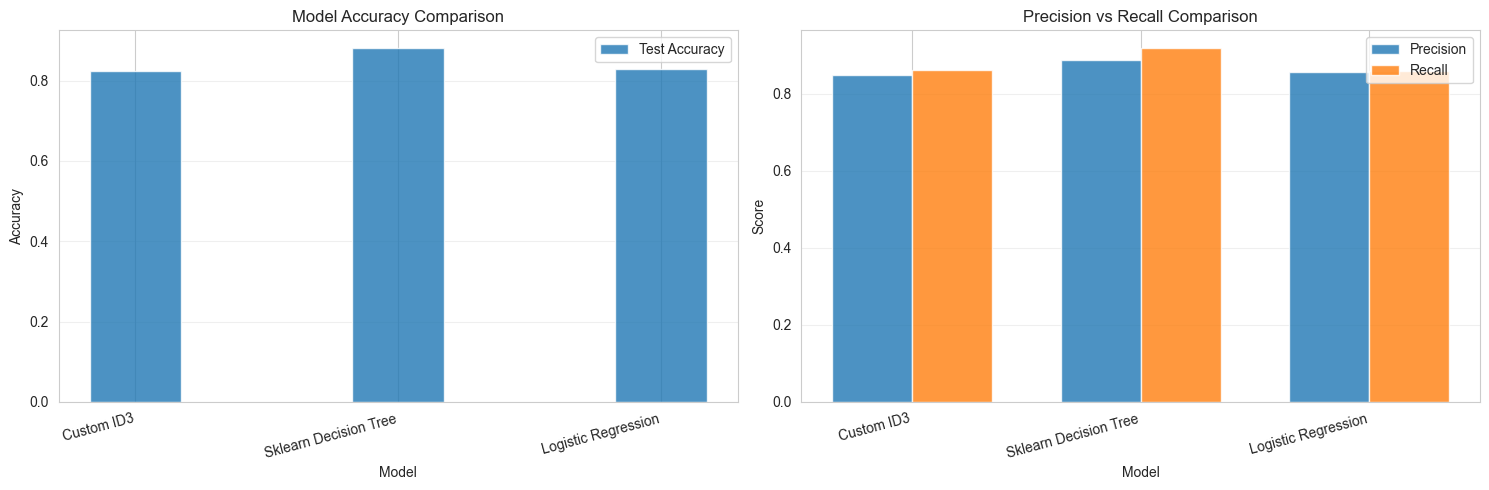

Best performing model: Sklearn Decision Tree


In [12]:
comparison_df = pd.DataFrame({
    'Model': ['Custom ID3', 'Sklearn Decision Tree', 'Logistic Regression'],

    'Test Accuracy': [
        id3_test_metrics["accuracy"],
        tree_test_metrics["accuracy"],
        log_test_metrics["accuracy"]
    ],
    'Test Precision': [
        id3_test_metrics["precision"],
        tree_test_metrics["precision"],
        log_test_metrics["precision"]
    ],
    'Test Recall': [
        id3_test_metrics["recall"],
        tree_test_metrics["recall"],
        log_test_metrics["recall"]
    ],
    'Train-Test Gap': [
        id3_train_metrics["accuracy"] - id3_test_metrics["accuracy"],
        tree_train_metrics["accuracy"] - tree_test_metrics["accuracy"],
        log_train_metrics["accuracy"] - log_test_metrics["accuracy"]
    ]
})

print("\nModel Comparison:")
print(comparison_df.to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x, comparison_df['Test Accuracy'], width, label='Test Accuracy', alpha=0.8)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - width/2, comparison_df['Test Precision'], width, label='Precision', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Test Recall'], width, label='Recall', alpha=0.8)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision vs Recall Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

best_model_idx = comparison_df['Test Accuracy'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Model']

print(f"Best performing model: {best_model}")

### 3.2d Visualizing the decision tree structure

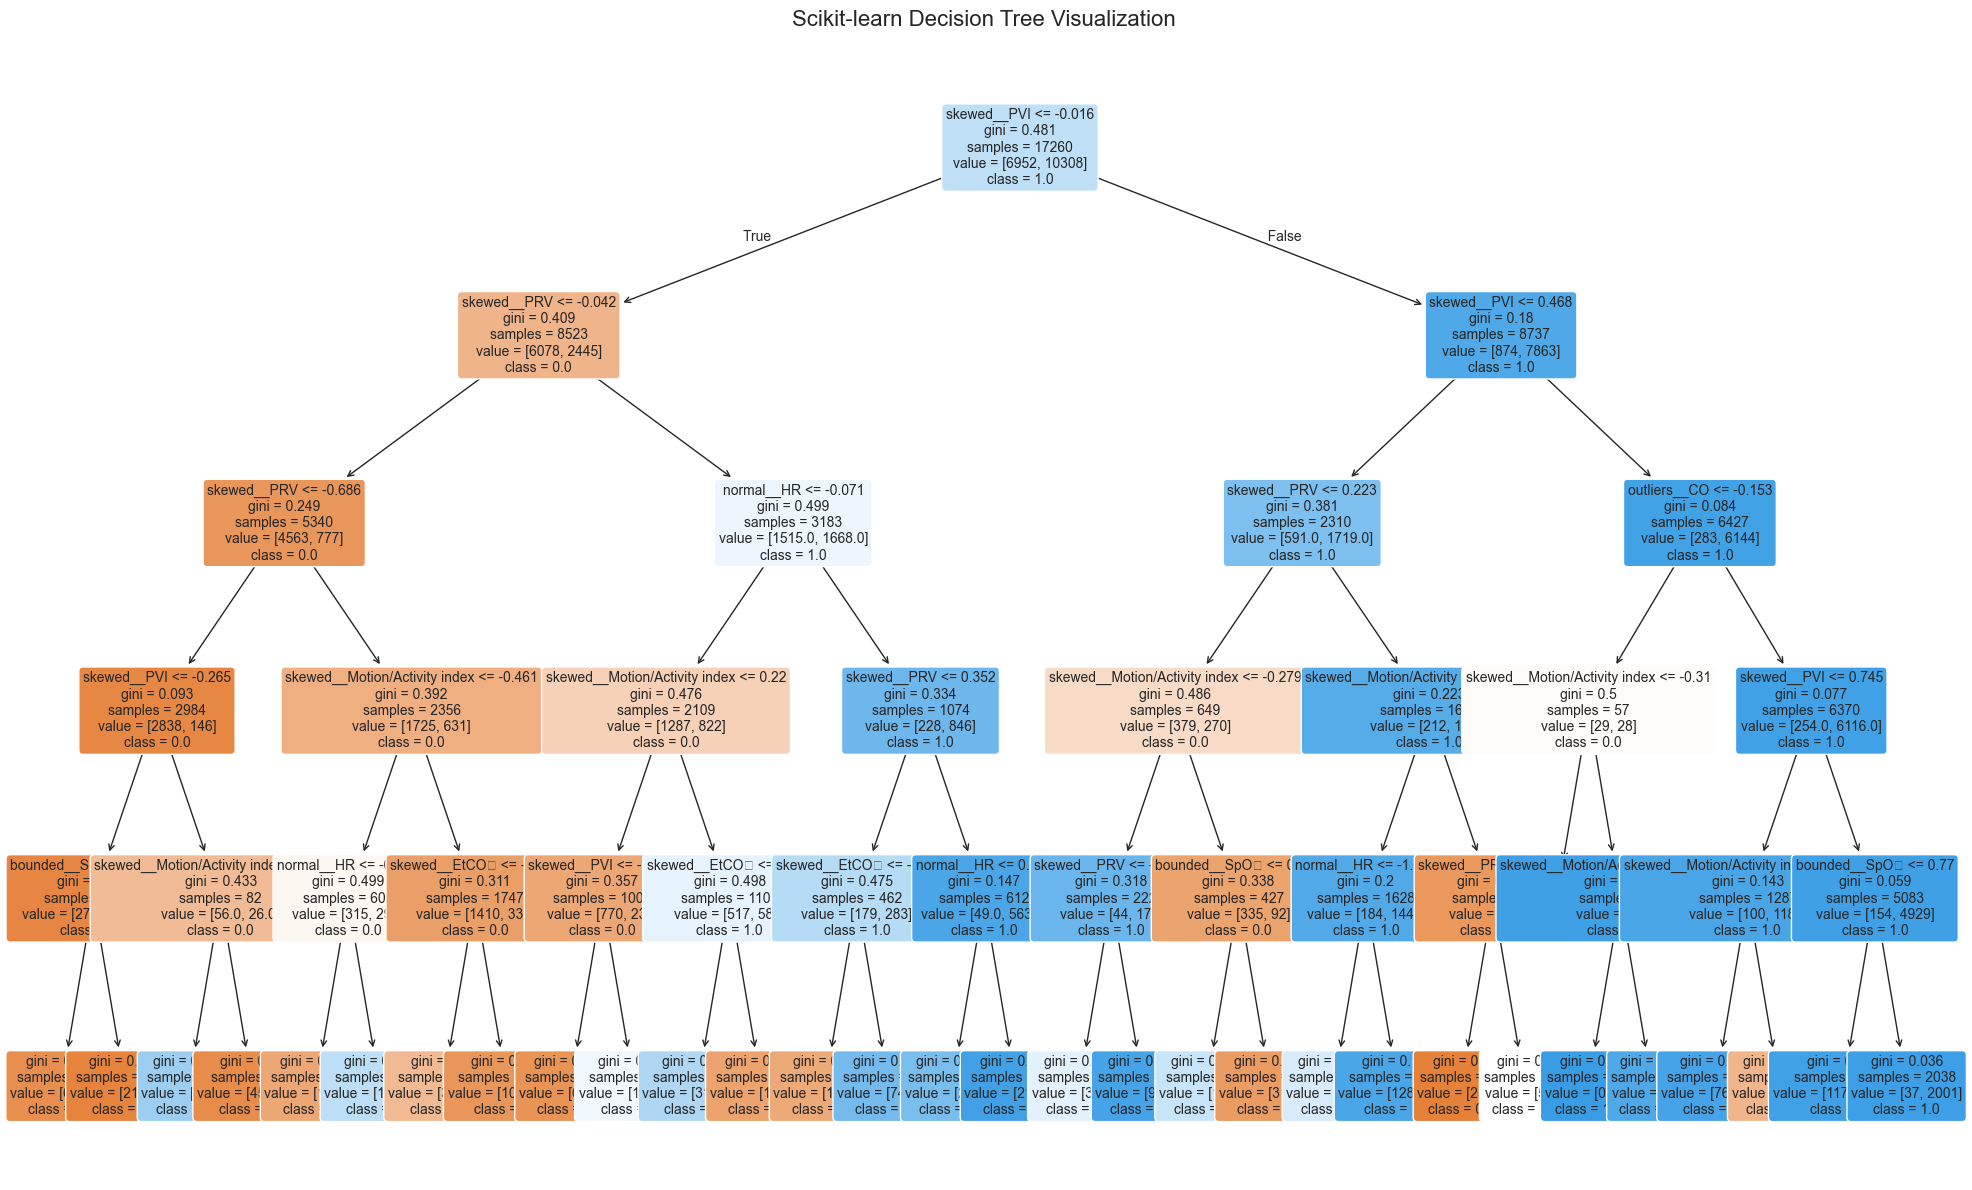

In [13]:
plt.figure(figsize=(20, 12))
plot_tree(
    sklearn_tree,
    feature_names=X_train.columns,
    class_names=[str(c) for c in sklearn_tree.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Scikit-learn Decision Tree Visualization', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': sklearn_tree.feature_importances_
}).sort_values('Importance', ascending=False)

## 3.3 Optimalizácia alias hyperparameter tuning

### 3.3a Nastavenie hyperparametrov

In [14]:
print("Hyperparameter Tuning for Decision Tree:")

param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [10, 20, 50, 100],
    'min_samples_leaf': [5, 10, 20, 30],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

tuned_tree = grid_search.best_estimator_

tuned_train = tuned_tree.predict(X_train)
tuned_test = tuned_tree.predict(X_test)

tuned_train_metrics = get_metrics(y_train, tuned_train)
tuned_test_metrics = get_metrics(y_test, tuned_test)

print("\nTuned Decision Tree:")
print(f"\t\t\tTraining\tTesting")
print(f"Accuracy:\t{tuned_train_metrics["accuracy"]:.2f}\t\t{tuned_test_metrics["accuracy"]:.2f}")
print(f"Precision:\t{tuned_train_metrics["precision"]:.2f}\t\t{tuned_test_metrics["precision"]:.2f}")
print(f"Recall:\t\t{tuned_train_metrics["recall"]:.2f}\t\t{tuned_test_metrics["recall"]:.2f}")

Hyperparameter Tuning for Decision Tree:
Fitting 5 folds for each of 160 candidates, totalling 800 fits

Best parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best cross-validation score: 0.9256

Tuned Decision Tree:
			Training	Testing
Accuracy:	0.96		0.93
Precision:	0.97		0.94
Recall:		0.97		0.95


### 3.3b Kombinácie modelov (ensemble)

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_train = rf_model.predict(X_train)
rf_test = rf_model.predict(X_test)

rf_train_metrics = get_metrics(y_train, rf_train)
rf_test_metrics = get_metrics(y_test, rf_test)

print("\nRandom Forest Classifier Metrics")
print("\t\t\tTraining\tTesting")
print(f"Accuracy:\t{rf_train_metrics["accuracy"]:.2f}\t\t{rf_test_metrics["accuracy"]:.2f}")
print(f"Precision:\t{rf_train_metrics["precision"]:.2f}\t\t{rf_test_metrics["precision"]:.2f}")
print(f"Recall:\t\t{rf_train_metrics["recall"]:.2f}\t\t{rf_test_metrics["recall"]:.2f}")



gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_train = gb_model.predict(X_train)
gb_test = gb_model.predict(X_test)

gb_train_metrics = get_metrics(y_train, gb_train)
gb_test_metrics = get_metrics(y_test, gb_test)

print("\nGradient Boosting Classifier Metrics")
print("\t\t\tTraining\tTesting")
print(f"Accuracy:\t{gb_train_metrics["accuracy"]:.2f}\t\t{gb_test_metrics["accuracy"]:.2f}")
print(f"Precision:\t{gb_train_metrics["precision"]:.2f}\t\t{gb_test_metrics["precision"]:.2f}")
print(f"Recall:\t\t{gb_train_metrics["recall"]:.2f}\t\t{gb_test_metrics["recall"]:.2f}")


voting_clf = VotingClassifier(
    estimators=[
        ('dt', tuned_tree),
        ('rf', rf_model),
        ('gb', gb_model)
    ],
    voting='hard'
)

voting_clf.fit(X_train, y_train)

voting_train = voting_clf.predict(X_train)
voting_test = voting_clf.predict(X_test)

voting_train_metrics = get_metrics(y_train, voting_train)
voting_test_metrics = get_metrics(y_test, voting_test)

print("\nVoting Ensemble Classifier Metrics")
print("\t\t\tTraining\tTesting")
print(f"Accuracy:\t{voting_train_metrics["accuracy"]:.2f}\t\t{voting_test_metrics["accuracy"]:.2f}")
print(f"Precision:\t{voting_train_metrics["precision"]:.2f}\t\t{voting_test_metrics["precision"]:.2f}")
print(f"Recall:\t\t{voting_train_metrics["recall"]:.2f}\t\t{voting_test_metrics["recall"]:.2f}")



Random Forest Classifier Metrics
			Training	Testing
Accuracy:	0.94		0.93
Precision:	0.96		0.95
Recall:		0.95		0.93

Gradient Boosting Classifier Metrics
			Training	Testing
Accuracy:	0.95		0.93
Precision:	0.96		0.95
Recall:		0.95		0.94

Voting Ensemble Classifier Metrics
			Training	Testing
Accuracy:	0.95		0.94
Precision:	0.97		0.95
Recall:		0.96		0.94


### 3.3c Cross validation

In [16]:
print("Cross-Validation (5-fold):\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Tuned Decision Tree': tuned_tree,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
    'Voting Ensemble': voting_clf
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    print(f"{name}:")
    print(f"  Mean Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"  All folds: {[f'{s:.4f}' for s in scores]}")
    print()

Cross-Validation (5-fold):

Tuned Decision Tree:
  Mean Accuracy: 0.9220 (+/- 0.0046)
  All folds: ['0.9177', '0.9160', '0.9227', '0.9284', '0.9253']

Random Forest:
  Mean Accuracy: 0.9276 (+/- 0.0037)
  All folds: ['0.9290', '0.9218', '0.9250', '0.9308', '0.9316']

Gradient Boosting:
  Mean Accuracy: 0.9295 (+/- 0.0014)
  All folds: ['0.9287', '0.9287', '0.9287', '0.9290', '0.9322']

Voting Ensemble:
  Mean Accuracy: 0.9338 (+/- 0.0027)
  All folds: ['0.9331', '0.9296', '0.9328', '0.9368', '0.9368']



### 3.3d Overfitting

In [17]:
print("Gap Analysis\n")

tuned_train_test_gap = tuned_train_metrics["accuracy"] - tuned_test_metrics["accuracy"]

print(f"Training Accuracy:\t{tuned_train_metrics["accuracy"]:.4f}")
print(f"Test Accuracy:\t\t{tuned_test_metrics["accuracy"]:.4f}")
print(f"Performance Gap:\t{tuned_train_test_gap:.4f}")

if tuned_train_test_gap < 0.05:
    print("\nGap < 5% - No overfitting detected")
elif tuned_train_test_gap < 0.10:
    print("\nGap < 10% - Minimal overfitting")
elif tuned_train_test_gap > 0.20:
    print("\nGap > 20% - Overfitting")
else:
    print("\nGap > 10% - Potential overfitting")


Gap Analysis

Training Accuracy:	0.9645
Test Accuracy:		0.9326
Performance Gap:	0.0320

Gap < 5% - No overfitting detected


Learning Curve Analysis



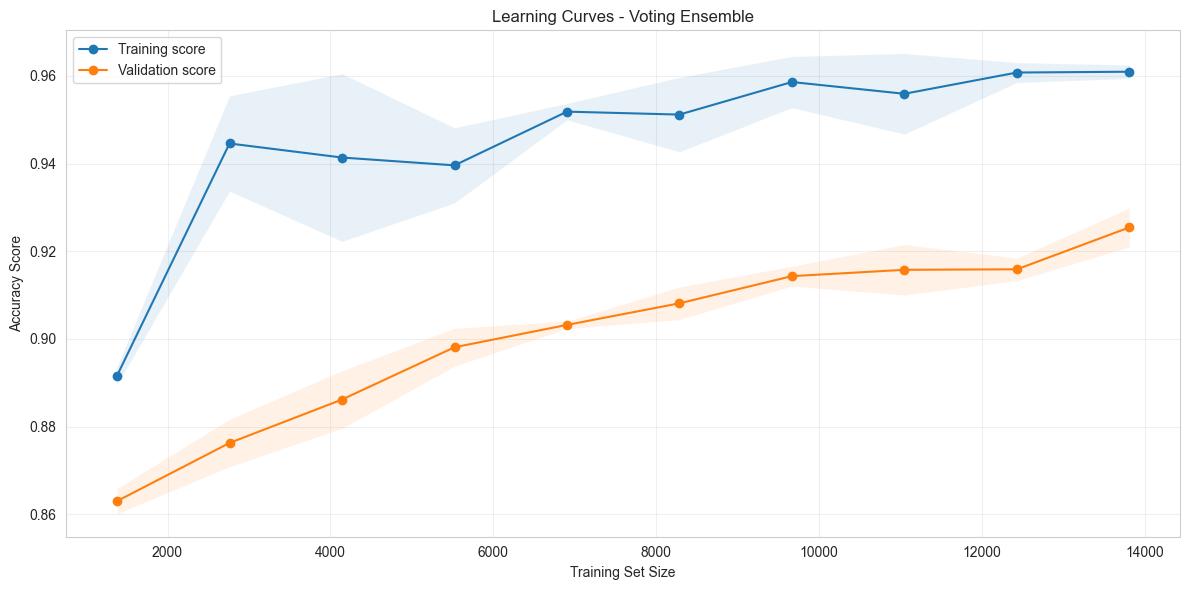


Learning curves show convergence — No overfitting


In [18]:
print("Learning Curve Analysis\n")

train_sizes, train_scores, val_scores = learning_curve(
    grid_search,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Training score')
plt.plot(train_sizes, val_mean, 'o-', label='Validation score')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.1)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.1)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy Score")
plt.title("Learning Curves - Voting Ensemble")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

final_gap = train_mean[-1] - val_mean[-1]
curves_converging = val_mean[-1] > val_mean[-3]

if curves_converging:
    print("\nLearning curves show convergence — No overfitting")
else:
    print("\nLearning curves suggest potential overfitting")


In [19]:
print("Cross-Validation Stability Analysis\n")

tuned_cv_scores = cv_results['Voting Ensemble']['scores']
tuned_cv_mean = cv_results['Voting Ensemble']['mean']
tuned_cv_std = cv_results['Voting Ensemble']['std']

print(f"Cross-validation scores: {[f'{s:.4f}' for s in tuned_cv_scores]}")
print(f"Mean CV score: {tuned_cv_mean:.4f}")
print(f"Std CV score: {tuned_cv_std:.4f}")

print(f"Test accuracy: {tuned_test_metrics["accuracy"]:.4f}")

cv_test_diff = abs(tuned_cv_mean - tuned_test_metrics["accuracy"])
print(f"Difference (CV vs Test): {cv_test_diff:.4f}")

if tuned_cv_std < 0.05 and cv_test_diff < 0.05:
    print("\nModel shows stable performance across folds — No overfitting")
elif tuned_cv_std < 0.10:
    print("\nModel shows acceptable stability — Minimal overfitting risk")
else:
    print("\nHigh variance across folds — Potential overfitting")


Cross-Validation Stability Analysis

Cross-validation scores: ['0.9331', '0.9296', '0.9328', '0.9368', '0.9368']
Mean CV score: 0.9338
Std CV score: 0.0027
Test accuracy: 0.9326
Difference (CV vs Test): 0.0013

Model shows stable performance across folds — No overfitting


## 3.4 Vyhodnotenie vplyvu zvolenej stratégie riešenia na klasifikáciu

### 3.4a Stratégie riešenia v data preprocessingu

In [20]:
observation_df = pd.read_csv('../data/observation.csv', sep='\t')

y_raw = observation_df['oximetry'].astype(int)

print("Only numeric data from observation.csv\n")

X_raw = observation_df.drop('oximetry', axis=1)

X_raw = X_raw.fillna(X_raw.median())

print(f"Dataset shape: {X_raw.shape}")
print(f"Features: {list(X_raw.columns)}")
print(f"Target distribution:\n{y_raw.value_counts()}\n")

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

print(f"Train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")

Only numeric data from observation.csv

Dataset shape: (12133, 22)
Features: ['SpO₂', 'HR', 'PI', 'RR', 'EtCO₂', 'FiO₂', 'PRV', 'BP', 'Skin Temperature', 'Motion/Activity index', 'PVI', 'Hb level', 'SV', 'CO', 'Blood Flow Index', 'PPG waveform features', 'Signal Quality Index', 'Respiratory effort', 'O₂ extraction ratio', 'SNR', 'latitude', 'longitude']
Target distribution:
oximetry
1    7237
0    4896
Name: count, dtype: int64

Train shape: (9706, 22), Test shape: (2427, 22)


In [21]:
sklearn_tree_raw = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

sklearn_tree_raw.fit(X_train_raw, y_train_raw)

tree_train_raw = sklearn_tree_raw.predict(X_train_raw)
tree_test_raw = sklearn_tree_raw.predict(X_test_raw)

tree_train_raw_metrics = get_metrics(tree_train_raw, y_train_raw)
tree_test_raw_metrics = get_metrics(tree_test_raw, y_test_raw)

logistic_model_raw = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='ovr'
)

logistic_model_raw.fit(X_train_raw, y_train_raw)

log_train_raw = logistic_model_raw.predict(X_train_raw)
log_test_raw = logistic_model_raw.predict(X_test_raw)

log_train_raw_metrics = get_metrics(log_train_raw, y_train_raw)
log_test_raw_metrics = get_metrics(log_test_raw, y_test_raw)

rf_model_raw = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_model_raw.fit(X_train_raw, y_train_raw)

rf_train_raw = rf_model_raw.predict(X_train_raw)
rf_test_raw = rf_model_raw.predict(X_test_raw)

rf_train_metrics_raw = get_metrics(rf_train_raw, y_train_raw)
rf_test_metrics_raw = get_metrics(rf_test_raw, y_test_raw)

In [22]:
print("Data after preprocessing\n")

y_train_prep = pd.read_csv("data/splits/y_train.csv").squeeze()
y_test_prep = pd.read_csv("data/splits/y_test.csv").squeeze()
X_train_prep = pd.read_csv("data/splits/X_train.csv")
X_test_prep = pd.read_csv("data/splits/X_test.csv")

print(f"Dataset B shape: {X_train_prep.shape}")
print(f"Features: {list(X_train_prep.columns)}")
print(f"Train shape: {X_train_prep.shape}, Test shape: {X_test_prep.shape}")

Data after preprocessing

Dataset B shape: (17260, 27)
Features: ['SpO₂', 'HR', 'PI', 'RR', 'EtCO₂', 'FiO₂', 'PRV', 'BP', 'Skin Temperature', 'Motion/Activity index', 'PVI', 'Hb level', 'SV', 'CO', 'Blood Flow Index', 'PPG waveform features', 'Signal Quality Index', 'Respiratory effort', 'O₂ extraction ratio', 'SNR', 'latitude', 'longitude', 'station', 'QoS', 'revision', 'continent', 'city']
Train shape: (17260, 27), Test shape: (4315, 27)


In [23]:
sklearn_tree_prep = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

sklearn_tree_prep.fit(X_train_prep, y_train_prep)

tree_train_prep = sklearn_tree_prep.predict(X_train_prep)
tree_test_prep = sklearn_tree_prep.predict(X_test_prep)

tree_train_prep_metrics = get_metrics(tree_train_prep, y_train_prep)
tree_test_prep_metrics = get_metrics(tree_test_prep, y_test_prep)

logistic_model_prep = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='ovr'
)

logistic_model_prep.fit(X_train_prep, y_train_prep)

log_train_prep = logistic_model_prep.predict(X_train_prep)
log_test_prep = logistic_model_prep.predict(X_test_prep)

log_train_prep_metrics = get_metrics(log_train_prep, y_train_prep)
log_test_prep_metrics = get_metrics(log_test_prep, y_test_prep)

rf_model_prep = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_model_prep.fit(X_train_prep, y_train_prep)

rf_train_prep = rf_model_prep.predict(X_train_prep)
rf_test_prep = rf_model_prep.predict(X_test_prep)

rf_train_metrics_prep = get_metrics(rf_train_prep, y_train_prep)
rf_test_metrics_prep = get_metrics(rf_test_prep, y_test_prep)

#### Porovnanie výkonnosti modelov trénovaných na surových dátach vs preprocessovaných dátach

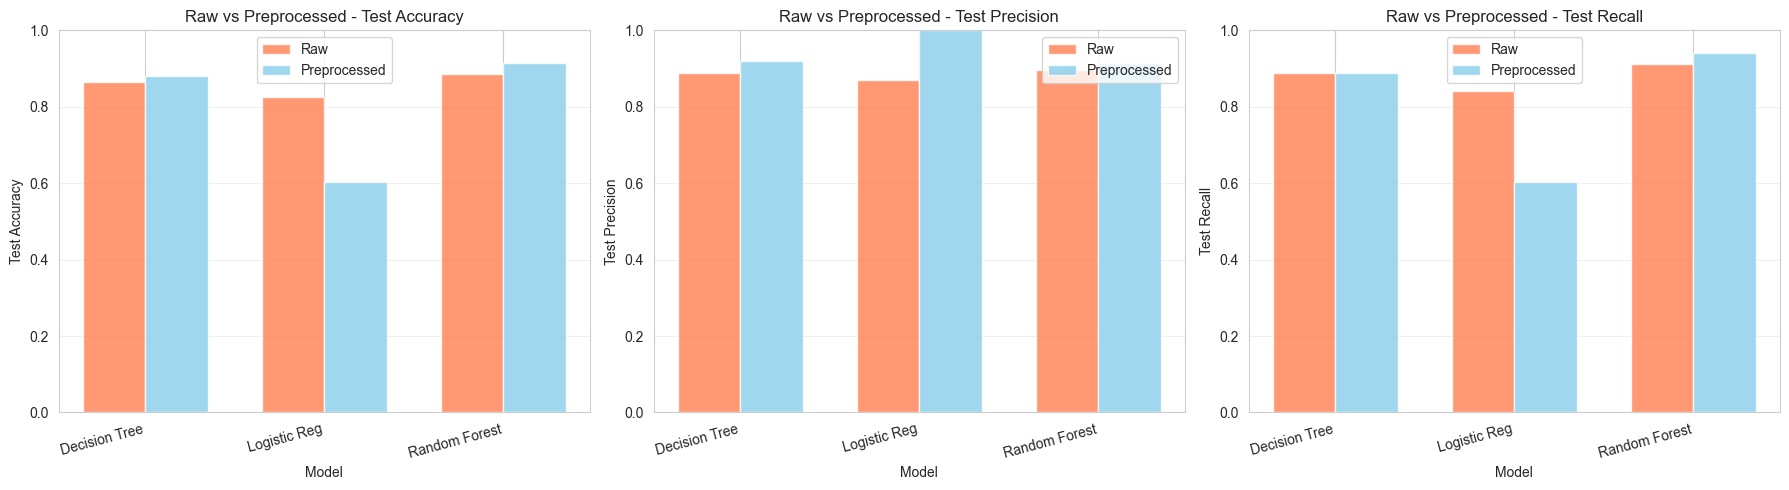


Comparison raw data vs preprocessed data:
                     Model  Test Accuracy  Test Precision  Test Recall  Train-Test Gap
       Decision Tree (raw)       0.865678        0.887431     0.887431        0.017384
      Decision Tree (prep)       0.880881        0.918846     0.887444        0.003650
 Logistic Regression (raw)       0.825299        0.870856     0.841789        0.008721
Logistic Regression (prep)       0.602549        1.000000     0.602549       -0.005330
       Random Forest (raw)       0.886691        0.895718     0.912738        0.040879
      Random Forest (prep)       0.914253        0.914615     0.941409        0.023812


Decision Tree Accuracy
  Raw:			0.8657
  Preprocessed:	0.8809
  Improvement:	1.52%

Logistic Reg Accuracy
  Raw:			0.8253
  Preprocessed:	0.6025
  Improvement:	-22.27%

Random Forest Accuracy
  Raw:			0.8867
  Preprocessed:	0.9143
  Improvement:	2.76%


In [24]:
raw_vs_prep_comparison = pd.DataFrame({
    'Model': [
        'Decision Tree (raw)',
        'Decision Tree (prep)',
        'Logistic Regression (raw)',
        'Logistic Regression (prep)',
        'Random Forest (raw)',
        'Random Forest (prep)'
    ],
    'Test Accuracy': [
        tree_test_raw_metrics["accuracy"],
        tree_test_prep_metrics["accuracy"],
        log_test_raw_metrics["accuracy"],
        log_test_prep_metrics["accuracy"],
        rf_test_metrics_raw["accuracy"],
        rf_test_metrics_prep["accuracy"]
    ],
    'Test Precision': [
        tree_test_raw_metrics["precision"],
        tree_test_prep_metrics["precision"],
        log_test_raw_metrics["precision"],
        log_test_prep_metrics["precision"],
        rf_test_metrics_raw["precision"],
        rf_test_metrics_prep["precision"]
    ],
    'Test Recall': [
        tree_test_raw_metrics["recall"],
        tree_test_prep_metrics["recall"],
        log_test_raw_metrics["recall"],
        log_test_prep_metrics["recall"],
        rf_test_metrics_raw["recall"],
        rf_test_metrics_prep["recall"]
    ],
    'Train-Test Gap': [
        tree_train_raw_metrics["accuracy"] - tree_test_raw_metrics["accuracy"],
        tree_train_prep_metrics["accuracy"] - tree_test_prep_metrics["accuracy"],
        log_train_raw_metrics["accuracy"] - log_test_raw_metrics["accuracy"],
        log_train_prep_metrics["accuracy"] - log_test_prep_metrics["accuracy"],
        rf_train_metrics_raw["accuracy"] - rf_test_metrics_raw["accuracy"],
        rf_train_metrics_prep["accuracy"] - rf_test_metrics_prep["accuracy"]
    ]
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_short = ['Decision Tree', 'Logistic Reg', 'Random Forest']
x = np.arange(len(models_short))
width = 0.35

raw_acc = [tree_test_raw_metrics["accuracy"], 
           log_test_raw_metrics["accuracy"],
           rf_test_metrics_raw["accuracy"]]
prep_acc = [tree_test_prep_metrics["accuracy"],
            log_test_prep_metrics["accuracy"],
            rf_test_metrics_prep["accuracy"]]

axes[0].bar(x - width/2, raw_acc, width, label='Raw', alpha=0.8, color='coral')
axes[0].bar(x + width/2, prep_acc, width, label='Preprocessed', alpha=0.8, color='skyblue')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Raw vs Preprocessed - Test Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_short, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

raw_prec = [tree_test_raw_metrics["precision"],
            log_test_raw_metrics["precision"],
            rf_test_metrics_raw["precision"]]
prep_prec = [tree_test_prep_metrics["precision"],
             log_test_prep_metrics["precision"],
             rf_test_metrics_prep["precision"]]

axes[1].bar(x - width/2, raw_prec, width, label='Raw', alpha=0.8, color='coral')
axes[1].bar(x + width/2, prep_prec, width, label='Preprocessed', alpha=0.8, color='skyblue')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Test Precision')
axes[1].set_title('Raw vs Preprocessed - Test Precision')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_short, rotation=15, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

raw_rec = [tree_test_raw_metrics["recall"],
           log_test_raw_metrics["recall"],
           rf_test_metrics_raw["recall"]]
prep_rec = [tree_test_prep_metrics["recall"],
            log_test_prep_metrics["recall"],
            rf_test_metrics_prep["recall"]]

axes[2].bar(x - width/2, raw_rec, width, label='Raw', alpha=0.8, color='coral')
axes[2].bar(x + width/2, prep_rec, width, label='Preprocessed', alpha=0.8, color='skyblue')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('Test Recall')
axes[2].set_title('Raw vs Preprocessed - Test Recall')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models_short, rotation=15, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\nComparison raw data vs preprocessed data:")
print(raw_vs_prep_comparison.to_string(index=False))
print()

for i, model_name in enumerate(models_short):
    improvement = (prep_acc[i] - raw_acc[i]) * 100
    print(f"\n{model_name} Accuracy")
    print(f"  Raw:\t\t\t{raw_acc[i]:.4f}")
    print(f"  Preprocessed:\t{prep_acc[i]:.4f}")
    print(f"  Improvement:\t{improvement:.2f}%")

Decision Tree a Random Forest ukázali mierne zlepšenie výsledkov, ale Logistic Regression dokonca ukázal horšie výsledky po spracovaní. Je to pravdepodobne spôsobené tým, že spájame tabuľky a získavame oveľa viac príznakov, ktoré komplikujú modelom pochopenie potrebných závislostí.

### 3.4b Porovnanie výkonnosti modelov trénovaných na preprocessovaných dátach vs modelov trénovaných na scalovaných dátach s feature selection

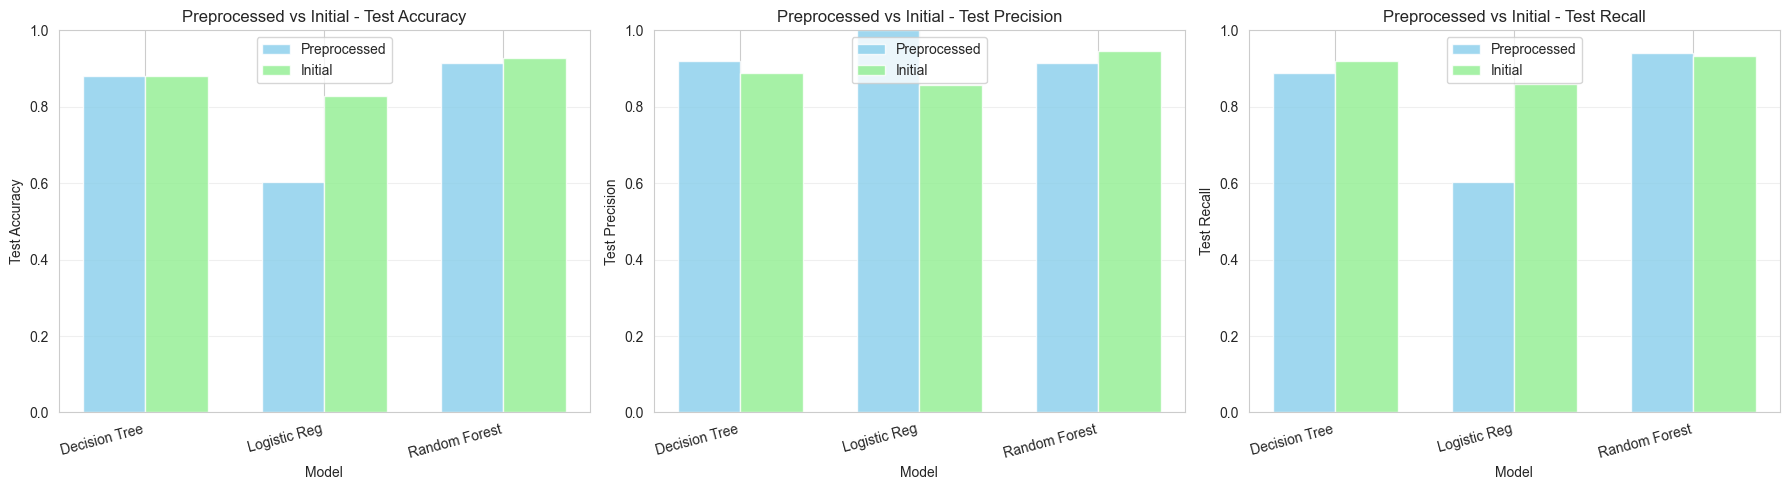

Comparison preprocessed data vs data with feature selection, scaling

                        Model  Test Accuracy  Test Precision  Test Recall  Train-Test Gap
         Decision Tree (prep)       0.880881        0.918846     0.887444        0.003650
      Decision Tree (Initial)       0.880881        0.887444     0.918846        0.003650
   Logistic Regression (prep)       0.602549        1.000000     0.602549       -0.005330
Logistic Regression (Initial)       0.828737        0.856377     0.860000        0.004345
         Random Forest (prep)       0.914253        0.914615     0.941409        0.023812
      Random Forest (Initial)       0.928158        0.945872     0.934231        0.015238


Decision Tree Accuracy
  Preprocessed:	0.8809
  Initial:		0.8809
  Improvement:	0.00%

Logistic Reg Accuracy
  Preprocessed:	0.6025
  Initial:		0.8287
  Improvement:	22.62%

Random Forest Accuracy
  Preprocessed:	0.9143
  Initial:		0.9282
  Improvement:	1.39%


In [25]:
prep_vs_initial_comparison = pd.DataFrame({
    'Model': [
        'Decision Tree (prep)',
        'Decision Tree (Initial)',
        'Logistic Regression (prep)',
        'Logistic Regression (Initial)',
        'Random Forest (prep)',
        'Random Forest (Initial)'
    ],
    'Test Accuracy': [
        tree_test_prep_metrics["accuracy"],
        tree_test_metrics["accuracy"],
        log_test_prep_metrics["accuracy"],
        log_test_metrics["accuracy"],
        rf_test_metrics_prep["accuracy"],
        rf_test_metrics["accuracy"]
    ],
    'Test Precision': [
        tree_test_prep_metrics["precision"],
        tree_test_metrics["precision"],
        log_test_prep_metrics["precision"],
        log_test_metrics["precision"],
        rf_test_metrics_prep["precision"],
        rf_test_metrics["precision"]
    ],
    'Test Recall': [
        tree_test_prep_metrics["recall"],
        tree_test_metrics["recall"],
        log_test_prep_metrics["recall"],
        log_test_metrics["recall"],
        rf_test_metrics_prep["recall"],
        rf_test_metrics["recall"]
    ],
    'Train-Test Gap': [
        tree_train_prep_metrics["accuracy"] - tree_test_prep_metrics["accuracy"],
        tree_train_metrics["accuracy"] - tree_test_metrics["accuracy"],
        log_train_prep_metrics["accuracy"] - log_test_prep_metrics["accuracy"],
        log_train_metrics["accuracy"] - log_test_metrics["accuracy"],
        rf_train_metrics_prep["accuracy"] - rf_test_metrics_prep["accuracy"],
        rf_train_metrics["accuracy"] - rf_test_metrics["accuracy"]
    ]
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_short = ['Decision Tree', 'Logistic Reg', 'Random Forest']
x = np.arange(len(models_short))
width = 0.35

prep_acc = [tree_test_prep_metrics["accuracy"],
            log_test_prep_metrics["accuracy"],
            rf_test_metrics_prep["accuracy"]]
initial_acc = [tree_test_metrics["accuracy"],
               log_test_metrics["accuracy"],
               rf_test_metrics["accuracy"]]

axes[0].bar(x - width/2, prep_acc, width, label='Preprocessed', alpha=0.8, color='skyblue')
axes[0].bar(x + width/2, initial_acc, width, label='Initial', alpha=0.8, color='lightgreen')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Preprocessed vs Initial - Test Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_short, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

prep_prec = [tree_test_prep_metrics["precision"],
             log_test_prep_metrics["precision"],
             rf_test_metrics_prep["precision"]]
initial_prec = [tree_test_metrics["precision"],
                log_test_metrics["precision"],
                rf_test_metrics["precision"]]

axes[1].bar(x - width/2, prep_prec, width, label='Preprocessed', alpha=0.8, color='skyblue')
axes[1].bar(x + width/2, initial_prec, width, label='Initial', alpha=0.8, color='lightgreen')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Test Precision')
axes[1].set_title('Preprocessed vs Initial - Test Precision')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_short, rotation=15, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

prep_rec = [tree_test_prep_metrics["recall"],
            log_test_prep_metrics["recall"],
            rf_test_metrics_prep["recall"]]
initial_rec = [tree_test_metrics["recall"],
               log_test_metrics["recall"],
               rf_test_metrics["recall"]]

axes[2].bar(x - width/2, prep_rec, width, label='Preprocessed', alpha=0.8, color='skyblue')
axes[2].bar(x + width/2, initial_rec, width, label='Initial', alpha=0.8, color='lightgreen')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('Test Recall')
axes[2].set_title('Preprocessed vs Initial - Test Recall')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models_short, rotation=15, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("Comparison preprocessed data vs data with feature selection, scaling\n")
print(prep_vs_initial_comparison.to_string(index=False))

print()
for i, model_name in enumerate(models_short):
    diff = (initial_acc[i] - prep_acc[i]) * 100
    print(f"\n{model_name} Accuracy")
    print(f"  Preprocessed:\t{prep_acc[i]:.4f}")
    print(f"  Initial:\t\t{initial_acc[i]:.4f}")
    print(f"  Improvement:\t{diff:.2f}%")

Aj keď Decision Tree nepreukázal žiadne zmeny a Random Forest len sa mierne zlepšil, výkonnosť Logistic Regression modelu sa výrazne zlepšila.

- Redukcia z 27 na 7 najdôležitejších príznakov odstránila šum a zlepšila generalizáciu.

- Scaling transformácie pomohli algoritmom lepšie sa učiť z dát.

- Rýchlejšie trénovanie vďaka menšiemu počtu príznakov

### 3.4c Výber atribútov, výber algoritmov, hyperparameter tuning, ensemble learning

In [26]:
models_metrics = {
    "Custom ID3": id3_test_metrics,
    "Sklearn Decision Tree": tree_test_metrics,
    "Logistic Regression": log_test_metrics,
    "Tuned Decision Tree": tuned_test_metrics,
    "Random Forest": tree_test_metrics,
    "Gradient Boosting Classifier": tree_train_metrics,
    "Voting Classifier": tree_train_metrics,
}

df = pd.DataFrame.from_dict(models_metrics, orient="index")
df = df.sort_values(by="accuracy", ascending=False)

best_model = df.index[0]
best_row = df.iloc[0]

print("Model Comparison")
print(df)
print("\nBest model:")
print(f"{best_model} — accuracy={best_row['accuracy']:.4f}, "
      f"precision={best_row['precision']:.4f}, recall={best_row['recall']:.4f}")

Model Comparison
                              accuracy  precision    recall
Tuned Decision Tree           0.932561   0.940145  0.948462
Gradient Boosting Classifier  0.884531   0.885990  0.925786
Voting Classifier             0.884531   0.885990  0.925786
Sklearn Decision Tree         0.880881   0.887444  0.918846
Random Forest                 0.880881   0.887444  0.918846
Logistic Regression           0.828737   0.856377  0.860000
Custom ID3                    0.824797   0.849772  0.861538

Best model:
Tuned Decision Tree — accuracy=0.9326, precision=0.9401, recall=0.9485


Výber atribútov znížil množstvo informácií spracovávaných modelmi, takže zostali len tie najpotrebnejšie. Preto je pre modely ľahšie hľadať závislosti a učiť sa.

Výber algoritmov ukázal, že Tuned Decision Tree je pre dané údaje najlepší.

Hľadanie potrebných hyperparametrov zlepšilo výkon modelu až tak, že dosiahol lepšie výsledky ako ensemble learning.

### 3.4d Najlepší model pre nasadenie

Ako najvýkonnejší a zároveň stabilný model sa ukázal Tuned Decision Tree, ktorý bol optimalizovaný pomocou GridSearchCV.

Tento model dosiahol najvyššie hodnoty metrík na testovacej množine:

Accuracy: 0.9326
Precision: 0.9401
Recall: 0.9485


Stabilita modelu bola potvrdená:

- nízkym train–test gap

- konzistentnými výsledkami v 5-fold cross-validation

- konvergujúcimi learning curves


Model je jednoduchý, interpretovateľný, rýchly na trénovanie a nevyžaduje ensemble prístupy. Napriek tomu prekonal všetky ostatné modely vrátane Random Forest, Gradient Boosting aj Voting Ensemble.

Preto je Tuned Decision Tree zvolený ako najlepší model pre nasadenie v produkčnom prostredí.

### 3.4e Data pipeline pre vybudovanie v produkcii

V trénovacej fáze bol použitý komplexný ColumnTransformer so 27 atribútmi, následne bol aplikovaný SelectKBest, ktorý vybral 7 najinformatívnejších transformovaných príznakov. Pre produkčné nasadenie je však možné tento proces výrazne zjednodušiť, pretože všetkých 7 vybraných príznakov pochádza z pôvodného datasetu observation.csv a nevyžadujú údaje zo station.csv.

Produkčný pipeline používa iba 7 vstupných atribútov z observation.csv. Tieto atribúty sú následne transformované rovnakými technikami, ktoré boli použité počas tréningu, a následne odovzdané modelu Tuned Decision Tree.

1. Vstupné dáta

Z pôvodného datasetu sa použije iba 7 atribútov:

HR – Heart rate
PRV – Pulse rate variability
PVI – Pleth variability index
EtCO – End-tidal CO2
Motion/Activity index
CO – Cardiac output
SpO – Peripheral oxygen saturation

Tieto atribúty boli vyhodnotené ako najinformatívnejšie.

2. Transformácia atribútov

StandardScaler používa sa na približne normálne rozdelenu veličinu:
HR

PowerTransformer používa sa na silne skosené distribúcie:
PRV
PVI
EtCO
Motion/Activity index

RobustScaler používa sa na atribút s veľkým počtom outlierov:
CO

MinMaxScaler používa sa pre veličinu viazanu na rozsah 0–100 %:
SpO

Výsledkom je 7 transformovaných príznakov presne v tvare, ktorý očakáva model.

3. Predikcia pomocou Tuned Decision Tree

Transformované dáta sa odovzdajú uloženému modelu Tuned Decision Tree
Model následne predikuje hodnotu oximetry ∈ {0, 1}

### Pipeline

In [30]:
INPUT_FEATURES = [
    "HR",
    "PRV",
    "PVI",
    "EtCO₂",
    "Motion/Activity index",
    "CO",
    "SpO₂"
]

production_preprocessor = ColumnTransformer(
    transformers=[
        ('HR', StandardScaler(), ["HR"]),
        ('PRV', PowerTransformer(), ["PRV"]),
        ('PVI', PowerTransformer(), ["PVI"]),
        ('EtCO', PowerTransformer(), ["EtCO₂"]),
        ('Motion_act_index', PowerTransformer(), ["Motion/Activity index"]),
        ('CO', RobustScaler(), ["CO"]),
        ('SpO', MinMaxScaler(), ["SpO₂"]),
    ],
    remainder='drop'
)

production_pipeline = Pipeline([
    ('preprocessor', production_preprocessor),
    ('model', tuned_tree)
])

df = pd.read_csv("../data/cleaned_data/observation.csv")

X = df[INPUT_FEATURES]
y = df["oximetry"].astype(int)

production_pipeline.fit(X, y)

joblib.dump(production_pipeline, "../data/production_pipeline.pkl")
joblib.dump(INPUT_FEATURES, "../data/production_features.pkl")

['../data/production_features.pkl']

### Pipeline functionality check

In [32]:
pipeline = joblib.load("../data/production_pipeline.pkl")
input_features = joblib.load("../data/production_features.pkl")

example_data = pd.DataFrame([{
    "HR": 88,
    "PRV": 76,
    "PVI": 12,
    "EtCO₂": 38,
    "Motion/Activity index": 9.1,
    "CO": 5.2,
    "SpO₂": 97,
}])

pred = pipeline.predict(example_data)
print("Predicted oximetry:", pred)

Predicted oximetry: [0]
